Extract averaged percent change in biological group biomass for each time period and contaminant release scenario location.

In [1]:
import os
import xarray as xr
import numpy as np
import pandas as pd
import itertools
from pathlib import Path
import geopandas as gpd
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import ssam_groups as groups
from mpl_toolkits.axes_grid1 import make_axes_locatable

### Define scenario and control files

In [2]:
control_root = Path('/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/Control/')
control_paths = sorted([p for p in control_root.glob('highres-control-3y-*/outputSalishSea.nc')])
for path in control_paths:
    print(path.parent.stem)

highres-control-3y-2019-2022
highres-control-3y-2029-2032
highres-control-3y-2039-2042


In [3]:
control_datasets = [xr.open_dataset(ctr,decode_cf=True) for ctr in control_paths]

In [4]:
control_datasets[0]

<xarray.Dataset>
Dimensions:                            (t: 366, b: 130, z: 7)
Coordinates:
  * t                                  (t) datetime64[ns] 2018-12-24T14:00:00...
Dimensions without coordinates: b, z
Data variables: (12/1010)
    volume                             (t, b, z) float64 ...
    hdsource                           (t, b, z) float64 ...
    hdsink                             (t, b, z) float64 ...
    eflux                              (t, b, z) float64 ...
    vflux                              (t, b, z) float64 ...
    porosity                           (t, b, z) float64 ...
    ...                                 ...
    Filter_feeder_Prop_Benzo           (t, b) float64 ...
    Sponges_Prop_Benzo                 (t, b) float64 ...
    Benthic_grazer_Prop_Benzo          (t, b) float64 ...
    Macrobenthos_Prop_Benzo            (t, b) float64 ...
    Macroalgae_Prop_Benzo              (t, b) float64 ...
    Seagrass_Prop_Benzo                (t, b) float64 ...
Attributes:
    title:       SalishSea
    geometry:    SS_xy.bgm
    parameters:  ./atlantisMerged -i init_conditions.nc 0 -o outputSalishSea....
    wcnz:        6
    sednz:       1

In [5]:
scenario_root = Path('/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI1/')
scenario_paths = sorted([p for p in scenario_root.glob('highres-*/outputSalishSea.nc')])
for path in scenario_paths:
    print(path.parent.stem, groups.conditions[str(path.parent.stem).split(sep = '_')[3]])

highres-2019-2022_4a_1_2019-07-04 low Fraser spring tide
highres-2019-2022_4a_2_2019-07-10 low Fraser neap tide
highres-2019-2022_4a_3_2020-07-22 high Fraser spring tide
highres-2019-2022_4a_4_2020-07-12 high Fraser neap tide
highres-2019-2022_5b_1_2019-01-20 low Fraser spring tide
highres-2019-2022_5b_2_2019-01-14 low Fraser neap tide
highres-2019-2022_5b_3_2020-01-24 high Fraser spring tide
highres-2019-2022_5b_4_2020-01-16 high Fraser neap tide
highres-2019-2022_6a_1_2019-07-16 low Fraser spring tide
highres-2019-2022_6a_2_2019-07-25 low Fraser neap tide
highres-2019-2022_6a_3_2020-07-21 high Fraser spring tide
highres-2019-2022_6a_4_2020-07-13 high Fraser neap tide
highres-2019-2022_7a_1_2019-01-21 low Fraser spring tide
highres-2019-2022_7a_2_2019-01-26 low Fraser neap tide
highres-2019-2022_7a_3_2020-01-11 high Fraser spring tide
highres-2019-2022_7a_4_2020-01-03 high Fraser neap tide
highres-2029-2039_4a_1_2019-07-04 low Fraser spring tide
highres-2029-2039_4a_2_2019-07-10 low F

In [6]:
scenario_datasets = [xr.open_dataset(scen,decode_cf=True) for scen in scenario_paths]

In [7]:
conditions_with_letters = {
    '1': 'FlTs',
    '2': 'FlTn',
    '3': 'FhTs',
    '4': 'FhTn',
    }

In [8]:
def average_boxplot_data_pelagic(bio_group, location=groups.salish_sea):
    all_results = []
    data_labels = ['spill year', '10 years later', '20 years later']

    for scenario, path in zip(scenario_datasets[0:16], scenario_paths[0:16]):
        control = control_datasets[0]
        nm = str(path.parent.stem).split(sep='_')
        year = str(nm[3])
        if nm[1] == '4a':
            scenario_name = 'AP-'+conditions_with_letters[nm[2]]
            hex_colour = '#863092'            
        elif nm[1] == '5b':
            scenario_name = 'TP-'+conditions_with_letters[nm[2]]
            hex_colour = '#6DB48E'
        elif nm[1] == '6a':
            scenario_name = 'EB-'+conditions_with_letters[nm[2]]
            hex_colour = '#2F61A4'
        elif nm[1] == '7a':
            scenario_name = 'JF-'+conditions_with_letters[nm[2]]
            hex_colour = '#A27170'

        group_ratio = 0
        for species in bio_group: 
            p_ratio = 0
            p_oiled = np.ma.filled(scenario.variables[bio_group[species] + '_N'][:, location, 0:6], np.nan)
            p_control = np.ma.filled(control.variables[bio_group[species] + '_N'][:, location, 0:6], np.nan)
        
            p_oiled = p_oiled.sum(axis=(1, 2)).mean()+groups.base_biomass[bio_group[species]]
            p_control = p_control.sum(axis=(1, 2)).mean()+groups.base_biomass[bio_group[species]]
            p_ratio = (p_oiled / p_control - 1) * 100
            
            all_results.append({
            'bio_group': species,
            'time_label': 'spill year',
            'scenario': scenario_name,
            'percent_change': p_ratio,
            'sensitivity': groups.sensitivity[bio_group[species]],
            'sensitivity_negative': -groups.sensitivity[bio_group[species]],
            })

    for scenario, path in zip(scenario_datasets[16:32], scenario_paths[16:32]):
        control = control_datasets[1]
        nm = str(path.parent.stem).split(sep='_')
        year = str(nm[3])
        if nm[1] == '4a':
            scenario_name = 'AP-'+conditions_with_letters[nm[2]]
            hex_colour = '#863092'            
        elif nm[1] == '5b':
            scenario_name = 'TP-'+conditions_with_letters[nm[2]]
            hex_colour = '#6DB48E'
        elif nm[1] == '6a':
            scenario_name = 'EB-'+conditions_with_letters[nm[2]]
            hex_colour = '#2F61A4'
        elif nm[1] == '7a':
            scenario_name = 'JF-'+conditions_with_letters[nm[2]]
            hex_colour = '#A27170'

        group_ratio = 0
        for species in bio_group: 
            p_ratio = 0
            p_oiled = np.ma.filled(scenario.variables[bio_group[species] + '_N'][:, location, 0:6], np.nan)
            p_control = np.ma.filled(control.variables[bio_group[species] + '_N'][:, location, 0:6], np.nan)
        
            p_oiled = p_oiled.sum(axis=(1, 2)).mean()+groups.base_biomass[bio_group[species]]
            p_control = p_control.sum(axis=(1, 2)).mean()+groups.base_biomass[bio_group[species]]
            p_ratio = (p_oiled / p_control - 1) * 100
            
            all_results.append({
            'bio_group': species,
            'time_label': '10 years later',
            'scenario': scenario_name,
            'percent_change': p_ratio,
            'sensitivity': groups.sensitivity[bio_group[species]],
            'sensitivity_negative': -groups.sensitivity[bio_group[species]],
            })

    for scenario, path in zip(scenario_datasets[32:len(scenario_datasets)+1], scenario_paths[32:len(scenario_datasets)+1]):
        control = control_datasets[2]
        nm = str(path.parent.stem).split(sep='_')
        year = str(nm[3])
        if nm[1] == '4a':
            scenario_name = 'AP-'+conditions_with_letters[nm[2]]
            hex_colour = '#863092'            
        elif nm[1] == '5b':
            scenario_name = 'TP-'+conditions_with_letters[nm[2]]
            hex_colour = '#6DB48E'
        elif nm[1] == '6a':
            scenario_name = 'EB-'+conditions_with_letters[nm[2]]
            hex_colour = '#2F61A4'
        elif nm[1] == '7a':
            scenario_name = 'JF-'+conditions_with_letters[nm[2]]
            hex_colour = '#A27170'

        group_ratio = 0
        for species in bio_group: 
            p_ratio = 0
            p_oiled = np.ma.filled(scenario.variables[bio_group[species] + '_N'][:, location, 0:6], np.nan)
            p_control = np.ma.filled(control.variables[bio_group[species] + '_N'][:, location, 0:6], np.nan)
        
            p_oiled = p_oiled.sum(axis=(1, 2)).mean()+groups.base_biomass[bio_group[species]]
            p_control = p_control.sum(axis=(1, 2)).mean()+groups.base_biomass[bio_group[species]]
            p_ratio = (p_oiled / p_control - 1) * 100
            
            all_results.append({
            'bio_group': species,
            'time_label': '20 years later',
            'scenario': scenario_name,
            'percent_change': p_ratio,
            'sensitivity': groups.sensitivity[bio_group[species]],
            'sensitivity_negative': -groups.sensitivity[bio_group[species]],
            })

    df = pd.DataFrame(all_results)
    df.to_csv("/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI1/averaged-data-"+bio_group[species]+".csv")

In [9]:
def average_boxplot_data_vertebrates(bio_group, location=groups.salish_sea):
    all_results = []
    data_labels = ['spill year', '10 years later', '20 years later']

    for scenario, path in zip(scenario_datasets[0:16], scenario_paths[0:16]):
        control = control_datasets[0]
        nm = str(path.parent.stem).split(sep='_')
        year = str(nm[3])
        if nm[1] == '4a':
            scenario_name = 'AP-'+conditions_with_letters[nm[2]]
            hex_colour = '#863092'            
        elif nm[1] == '5b':
            scenario_name = 'TP-'+conditions_with_letters[nm[2]]
            hex_colour = '#6DB48E'
        elif nm[1] == '6a':
            scenario_name = 'EB-'+conditions_with_letters[nm[2]]
            hex_colour = '#2F61A4'
        elif nm[1] == '7a':
            scenario_name = 'JF-'+conditions_with_letters[nm[2]]
            hex_colour = '#A27170'
            
        average_ratio = 0
        for species in bio_group:

            species_ratio = 0

            numCohorts = groups.cohorts[bio_group[species]]
            for cohort in range (1, numCohorts+1):
                new_species = bio_group[species] + str(cohort)
            
                o_numbers_tbl = np.ma.filled(scenario.variables[new_species + '_Nums'][:, location, 0:6], np.nan)
                o_structuralN_tbl = np.ma.filled(scenario.variables[new_species +'_StructN'][:, location, 0:6], np.nan)
                o_reservedN_tbl = np.ma.filled(scenario.variables[new_species +'_ResN'][:, location, 0:6], np.nan)

                c_numbers_tbl = np.ma.filled(control.variables[new_species + '_Nums'][:, location, 0:6], np.nan)
                c_structuralN_tbl = np.ma.filled(control.variables[new_species +'_StructN'][:, location, 0:6], np.nan)
                c_reservedN_tbl = np.ma.filled(control.variables[new_species +'_ResN'][:, location, 0:6], np.nan)

                o_weightatage_tbl = (o_structuralN_tbl + o_reservedN_tbl) * o_numbers_tbl 
                o_weightatage = o_weightatage_tbl.sum(axis=(1,2)).mean()

                c_weightatage_tbl = (c_structuralN_tbl + c_reservedN_tbl) * c_numbers_tbl 
                c_weightatage = c_weightatage_tbl.sum(axis=(1,2)).mean()

                cohort_ratio = (o_weightatage / c_weightatage - 1) * 100
                #print(scenario_name, species, cohort, cohort_ratio)
                species_ratio = species_ratio + cohort_ratio

            final_species_ratio = species_ratio/numCohorts
        
            all_results.append({
            'bio_group': species,
            'time_label': 'spill year',
            'scenario': scenario_name,
            'percent_change': final_species_ratio,
            'sensitivity': groups.sensitivity[bio_group[species]],
            'sensitivity_negative': -groups.sensitivity[bio_group[species]],
            })
    
    for scenario, path in zip(scenario_datasets[16:32], scenario_paths[16:32]):
        control = control_datasets[1]
        nm = str(path.parent.stem).split(sep='_')
        year = str(nm[3])
        if nm[1] == '4a':
            scenario_name = 'AP-'+conditions_with_letters[nm[2]]
            hex_colour = '#863092'            
        elif nm[1] == '5b':
            scenario_name = 'TP-'+conditions_with_letters[nm[2]]
            hex_colour = '#6DB48E'
        elif nm[1] == '6a':
            scenario_name = 'EB-'+conditions_with_letters[nm[2]]
            hex_colour = '#2F61A4'
        elif nm[1] == '7a':
            scenario_name = 'JF-'+conditions_with_letters[nm[2]]
            hex_colour = '#A27170'
            
        average_ratio = 0
        for species in bio_group:

            species_ratio = 0

            numCohorts = groups.cohorts[bio_group[species]]
            for cohort in range (1, numCohorts+1):
                new_species = bio_group[species] + str(cohort)
            
                o_numbers_tbl = np.ma.filled(scenario.variables[new_species + '_Nums'][:, location, 0:6], np.nan)
                o_structuralN_tbl = np.ma.filled(scenario.variables[new_species +'_StructN'][:, location, 0:6], np.nan)
                o_reservedN_tbl = np.ma.filled(scenario.variables[new_species +'_ResN'][:, location, 0:6], np.nan)

                c_numbers_tbl = np.ma.filled(control.variables[new_species + '_Nums'][:, location, 0:6], np.nan)
                c_structuralN_tbl = np.ma.filled(control.variables[new_species +'_StructN'][:, location, 0:6], np.nan)
                c_reservedN_tbl = np.ma.filled(control.variables[new_species +'_ResN'][:, location, 0:6], np.nan)

                o_weightatage_tbl = (o_structuralN_tbl + o_reservedN_tbl) * o_numbers_tbl 
                o_weightatage = o_weightatage_tbl.sum(axis=(1,2)).mean()

                c_weightatage_tbl = (c_structuralN_tbl + c_reservedN_tbl) * c_numbers_tbl 
                c_weightatage = c_weightatage_tbl.sum(axis=(1,2)).mean()

                cohort_ratio = (o_weightatage / c_weightatage - 1) * 100
                #print(scenario_name, species, cohort, cohort_ratio)
                species_ratio = species_ratio + cohort_ratio

            final_species_ratio = species_ratio/numCohorts
            
            all_results.append({
            'bio_group': species,
            'time_label': '10 years later',
            'scenario': scenario_name,
            'percent_change': final_species_ratio,
            'sensitivity': groups.sensitivity[bio_group[species]],
            'sensitivity_negative': -groups.sensitivity[bio_group[species]],
            })

    for scenario, path in zip(scenario_datasets[32:len(scenario_datasets)+1], scenario_paths[32:len(scenario_datasets)+1]):
        control = control_datasets[2]
        nm = str(path.parent.stem).split(sep='_')
        year = str(nm[3])
        if nm[1] == '4a':
            scenario_name = 'AP-'+conditions_with_letters[nm[2]]
            hex_colour = '#863092'            
        elif nm[1] == '5b':
            scenario_name = 'TP-'+conditions_with_letters[nm[2]]
            hex_colour = '#6DB48E'
        elif nm[1] == '6a':
            scenario_name = 'EB-'+conditions_with_letters[nm[2]]
            hex_colour = '#2F61A4'
        elif nm[1] == '7a':
            scenario_name = 'JF-'+conditions_with_letters[nm[2]]
            hex_colour = '#A27170'
            
        average_ratio = 0
        for species in bio_group:

            species_ratio = 0

            numCohorts = groups.cohorts[bio_group[species]]
            for cohort in range (1, numCohorts+1):
                new_species = bio_group[species] + str(cohort)
            
                o_numbers_tbl = np.ma.filled(scenario.variables[new_species + '_Nums'][:, location, 0:6], np.nan)
                o_structuralN_tbl = np.ma.filled(scenario.variables[new_species +'_StructN'][:, location, 0:6], np.nan)
                o_reservedN_tbl = np.ma.filled(scenario.variables[new_species +'_ResN'][:, location, 0:6], np.nan)

                c_numbers_tbl = np.ma.filled(control.variables[new_species + '_Nums'][:, location, 0:6], np.nan)
                c_structuralN_tbl = np.ma.filled(control.variables[new_species +'_StructN'][:, location, 0:6], np.nan)
                c_reservedN_tbl = np.ma.filled(control.variables[new_species +'_ResN'][:, location, 0:6], np.nan)

                o_weightatage_tbl = (o_structuralN_tbl + o_reservedN_tbl) * o_numbers_tbl 
                o_weightatage = o_weightatage_tbl.sum(axis=(1,2)).mean()

                c_weightatage_tbl = (c_structuralN_tbl + c_reservedN_tbl) * c_numbers_tbl 
                c_weightatage = c_weightatage_tbl.sum(axis=(1,2)).mean()

                cohort_ratio = (o_weightatage / c_weightatage - 1) * 100
                #print(scenario_name, species, cohort, cohort_ratio)
                species_ratio = species_ratio + cohort_ratio

            final_species_ratio = species_ratio/numCohorts
            
            all_results.append({
            'bio_group': species,
            'time_label': '20 years later',
            'scenario': scenario_name,
            'percent_change': final_species_ratio,
            'sensitivity': groups.sensitivity[bio_group[species]],
            'sensitivity_negative': -groups.sensitivity[bio_group[species]],
            })

    df = pd.DataFrame(all_results)
    df.to_csv("/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI1/averaged-data-"+bio_group[species]+".csv")

In [10]:
def average_boxplot_data_benthic(bio_group, location=groups.salish_sea):
    all_results = []
    data_labels = ['spill year', '10 years later', '20 years later']

    for scenario, path in zip(scenario_datasets[0:16], scenario_paths[0:16]):
        control = control_datasets[0]
        nm = str(path.parent.stem).split(sep='_')
        year = str(nm[3])
        if nm[1] == '4a':
            scenario_name = 'AP-'+conditions_with_letters[nm[2]]
            hex_colour = '#863092'           
        elif nm[1] == '5b':
            scenario_name = 'TP-'+conditions_with_letters[nm[2]]
            hex_colour = '#6DB48E'
        elif nm[1] == '6a':
            scenario_name = 'EB-'+conditions_with_letters[nm[2]]
            hex_colour = '#2F61A4'
        elif nm[1] == '7a':
            scenario_name = 'JF-'+conditions_with_letters[nm[2]]
            hex_colour = '#A27170'

        for species in bio_group: 
            p_oiled = np.ma.filled(scenario.variables[bio_group[species] + '_N'][:, location], np.nan)
            p_control = np.ma.filled(control.variables[bio_group[species] + '_N'][:, location], np.nan)
        
            p_oiled = p_oiled.sum(axis=1).mean()+groups.base_biomass[bio_group[species]]
            p_control = p_control.sum(axis=1).mean()+groups.base_biomass[bio_group[species]]
            p_ratio = (p_oiled / p_control - 1) * 100

            all_results.append({
            'bio_group': species,
            'time_label': 'spill year',
            'scenario': scenario_name,
            'percent_change': p_ratio,
            'sensitivity': groups.sensitivity[bio_group[species]],
            'sensitivity_negative': -groups.sensitivity[bio_group[species]],
            })
    
    for scenario, path in zip(scenario_datasets[16:32], scenario_paths[16:32]):
        control = control_datasets[1]
        nm = str(path.parent.stem).split(sep='_')
        year = str(nm[3])
        if nm[1] == '4a':
            scenario_name = 'AP-'+conditions_with_letters[nm[2]]
            hex_colour = '#863092'           
        elif nm[1] == '5b':
            scenario_name = 'TP-'+conditions_with_letters[nm[2]]
            hex_colour = '#6DB48E'
        elif nm[1] == '6a':
            scenario_name = 'EB-'+conditions_with_letters[nm[2]]
            hex_colour = '#2F61A4'
        elif nm[1] == '7a':
            scenario_name = 'JF-'+conditions_with_letters[nm[2]]
            hex_colour = '#A27170'

        for species in bio_group: 
            p_oiled = np.ma.filled(scenario.variables[bio_group[species] + '_N'][:, location], np.nan)
            p_control = np.ma.filled(control.variables[bio_group[species] + '_N'][:, location], np.nan)
        
            p_oiled = p_oiled.sum(axis=1).mean()+groups.base_biomass[bio_group[species]]
            p_control = p_control.sum(axis=1).mean()+groups.base_biomass[bio_group[species]]
            p_ratio = (p_oiled / p_control - 1) * 100
            
            all_results.append({
            'bio_group': species,
            'time_label': '10 years later',
            'scenario': scenario_name,
            'percent_change': p_ratio,
            'sensitivity': groups.sensitivity[bio_group[species]],
            'sensitivity_negative': -groups.sensitivity[bio_group[species]],
            })

    for scenario, path in zip(scenario_datasets[32:len(scenario_datasets)+1], scenario_paths[32:len(scenario_datasets)+1]):
        control = control_datasets[2]
        nm = str(path.parent.stem).split(sep='_')
        year = str(nm[3])
        if nm[1] == '4a':
            scenario_name = 'AP-'+conditions_with_letters[nm[2]]
            hex_colour = '#863092'           
        elif nm[1] == '5b':
            scenario_name = 'TP-'+conditions_with_letters[nm[2]]
            hex_colour = '#6DB48E'
        elif nm[1] == '6a':
            scenario_name = 'EB-'+conditions_with_letters[nm[2]]
            hex_colour = '#2F61A4'
        elif nm[1] == '7a':
            scenario_name = 'JF-'+conditions_with_letters[nm[2]]
            hex_colour = '#A27170'

        for species in bio_group: 
            p_oiled = np.ma.filled(scenario.variables[bio_group[species] + '_N'][:, location], np.nan)
            p_control = np.ma.filled(control.variables[bio_group[species] + '_N'][:, location], np.nan)
        
            p_oiled = p_oiled.sum(axis=1).mean()+groups.base_biomass[bio_group[species]]
            p_control = p_control.sum(axis=1).mean()+groups.base_biomass[bio_group[species]]
            p_ratio = (p_oiled / p_control - 1) * 100
            
            all_results.append({
            'bio_group': species,
            'time_label': '20 years later',
            'scenario': scenario_name,
            'percent_change': p_ratio,
            'sensitivity': groups.sensitivity[bio_group[species]],
            'sensitivity_negative': -groups.sensitivity[bio_group[species]],
            })

    df = pd.DataFrame(all_results)
    df.to_csv("/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI1/averaged-data-"+bio_group[species]+".csv")

In [11]:
average_boxplot_data_pelagic(groups.plankton)

In [12]:
average_boxplot_data_benthic(groups.benthic_invertebrates)

In [13]:
average_boxplot_data_benthic(groups.macroalgae)

In [14]:
average_boxplot_data_vertebrates(groups.salmon)

In [15]:
average_boxplot_data_vertebrates(groups.named_fish)

In [16]:
average_boxplot_data_vertebrates(groups.other_fish)

In [17]:
average_boxplot_data_vertebrates(groups.mammals)

In [18]:
average_boxplot_data_vertebrates(groups.sharks)

In [19]:
average_boxplot_data_vertebrates(groups.birds)

In [20]:
results_root = Path('/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI1/')
results_paths = sorted([p for p in results_root.glob('averaged-data-*.csv')])
averaged_data = []
for file in results_paths:
    df1 = pd.read_csv(file)
    averaged_data.append(df1[['bio_group', 'time_label','scenario', 'percent_change','sensitivity','sensitivity_negative']])

averaged_data_df = pd.concat(averaged_data, ignore_index=True)
averaged_data_df.to_csv("/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI1/averaged_data.csv")

In [21]:
df = pd.read_csv("/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI1/averaged_data.csv")

In [22]:
code_names = {'EB','AP','JF','TP'}

In [26]:
time_labels = df['time_label'].unique()
scenarios = df['scenario'].unique()
bio_groups = df['bio_group'].unique()

hatches = ['oo', '///', 'xx', '++']
alphas = [0.5, 0.75, 0.3, 1]
colors = plt.cm.tab10.colors

In [24]:
groups.birds

{'seagulls': 'Seabird_gulls', 'other seabirds': 'Seabirds'}

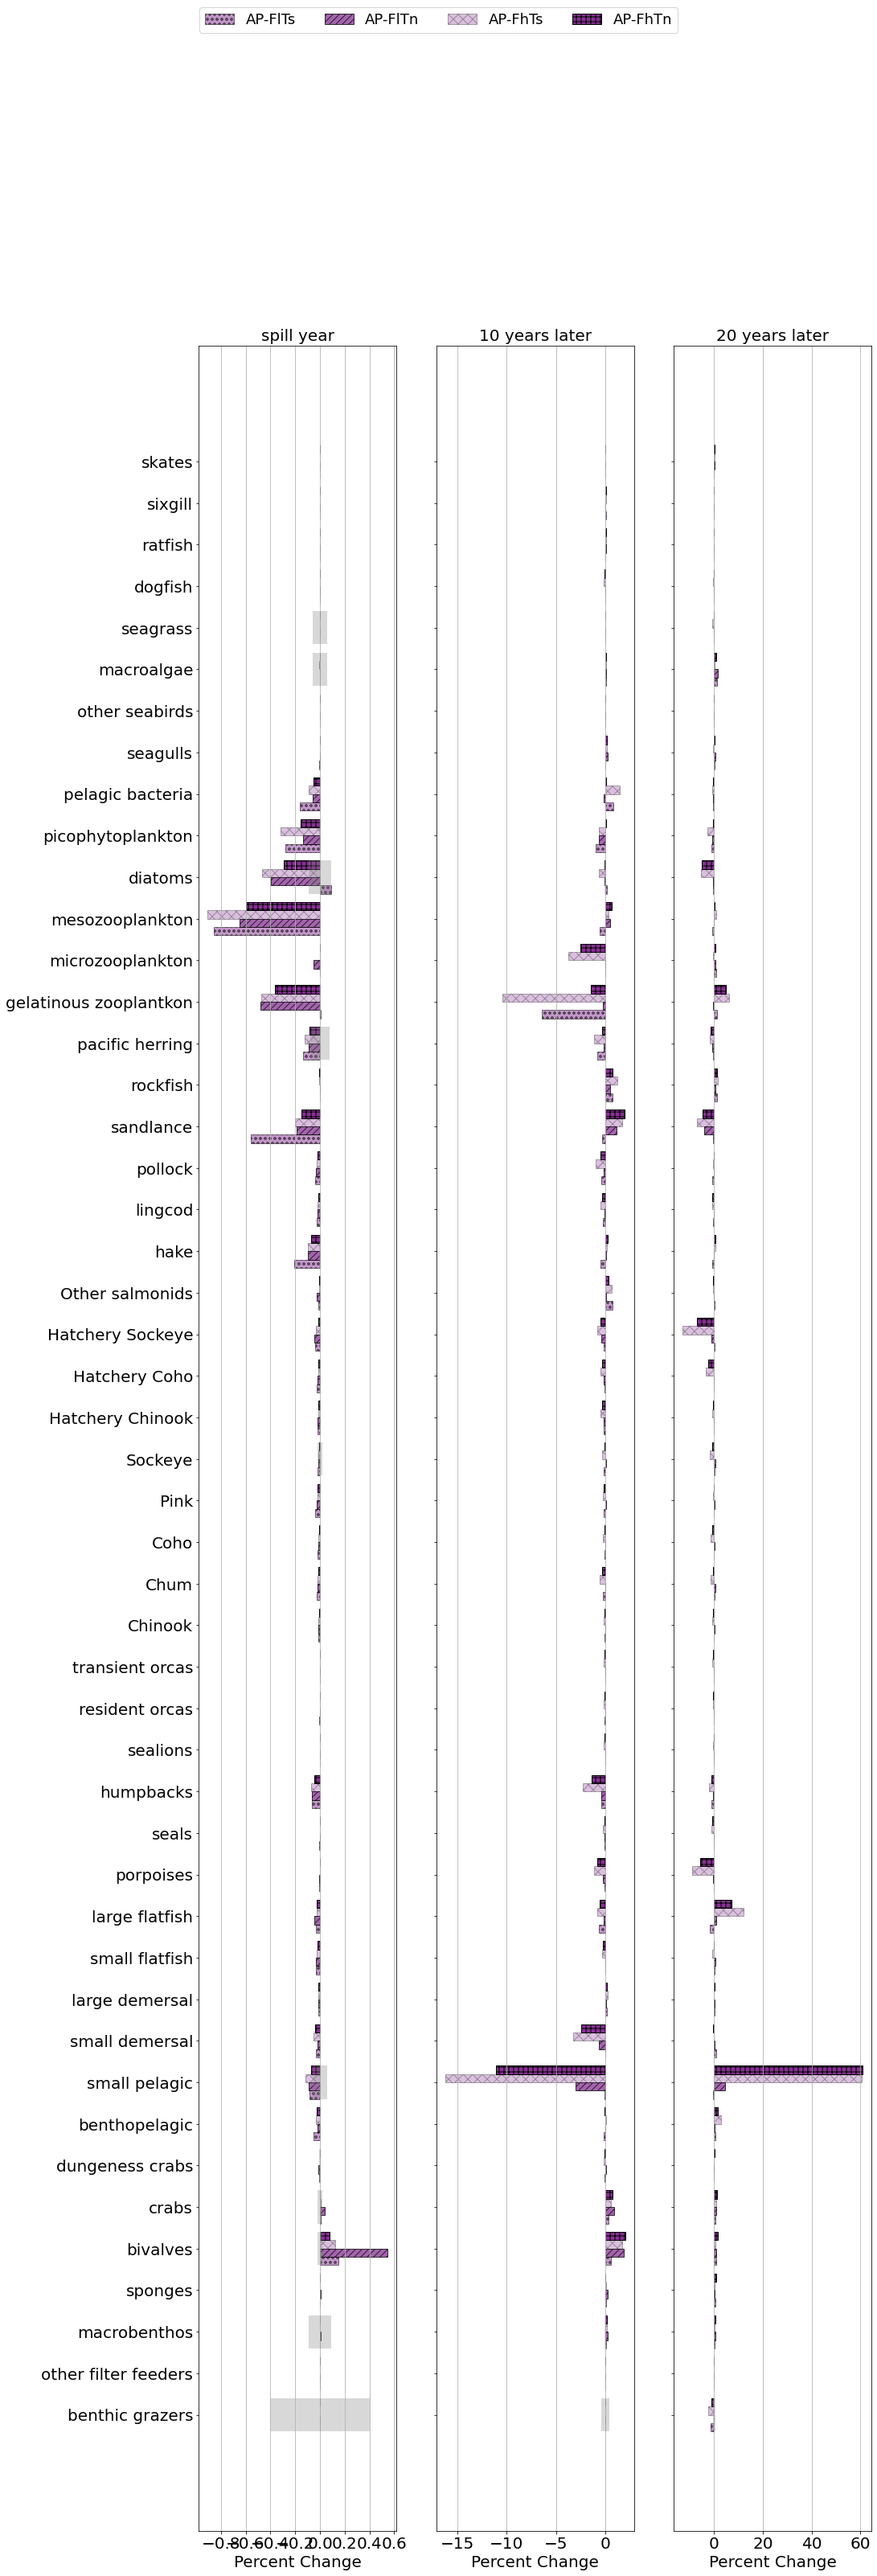

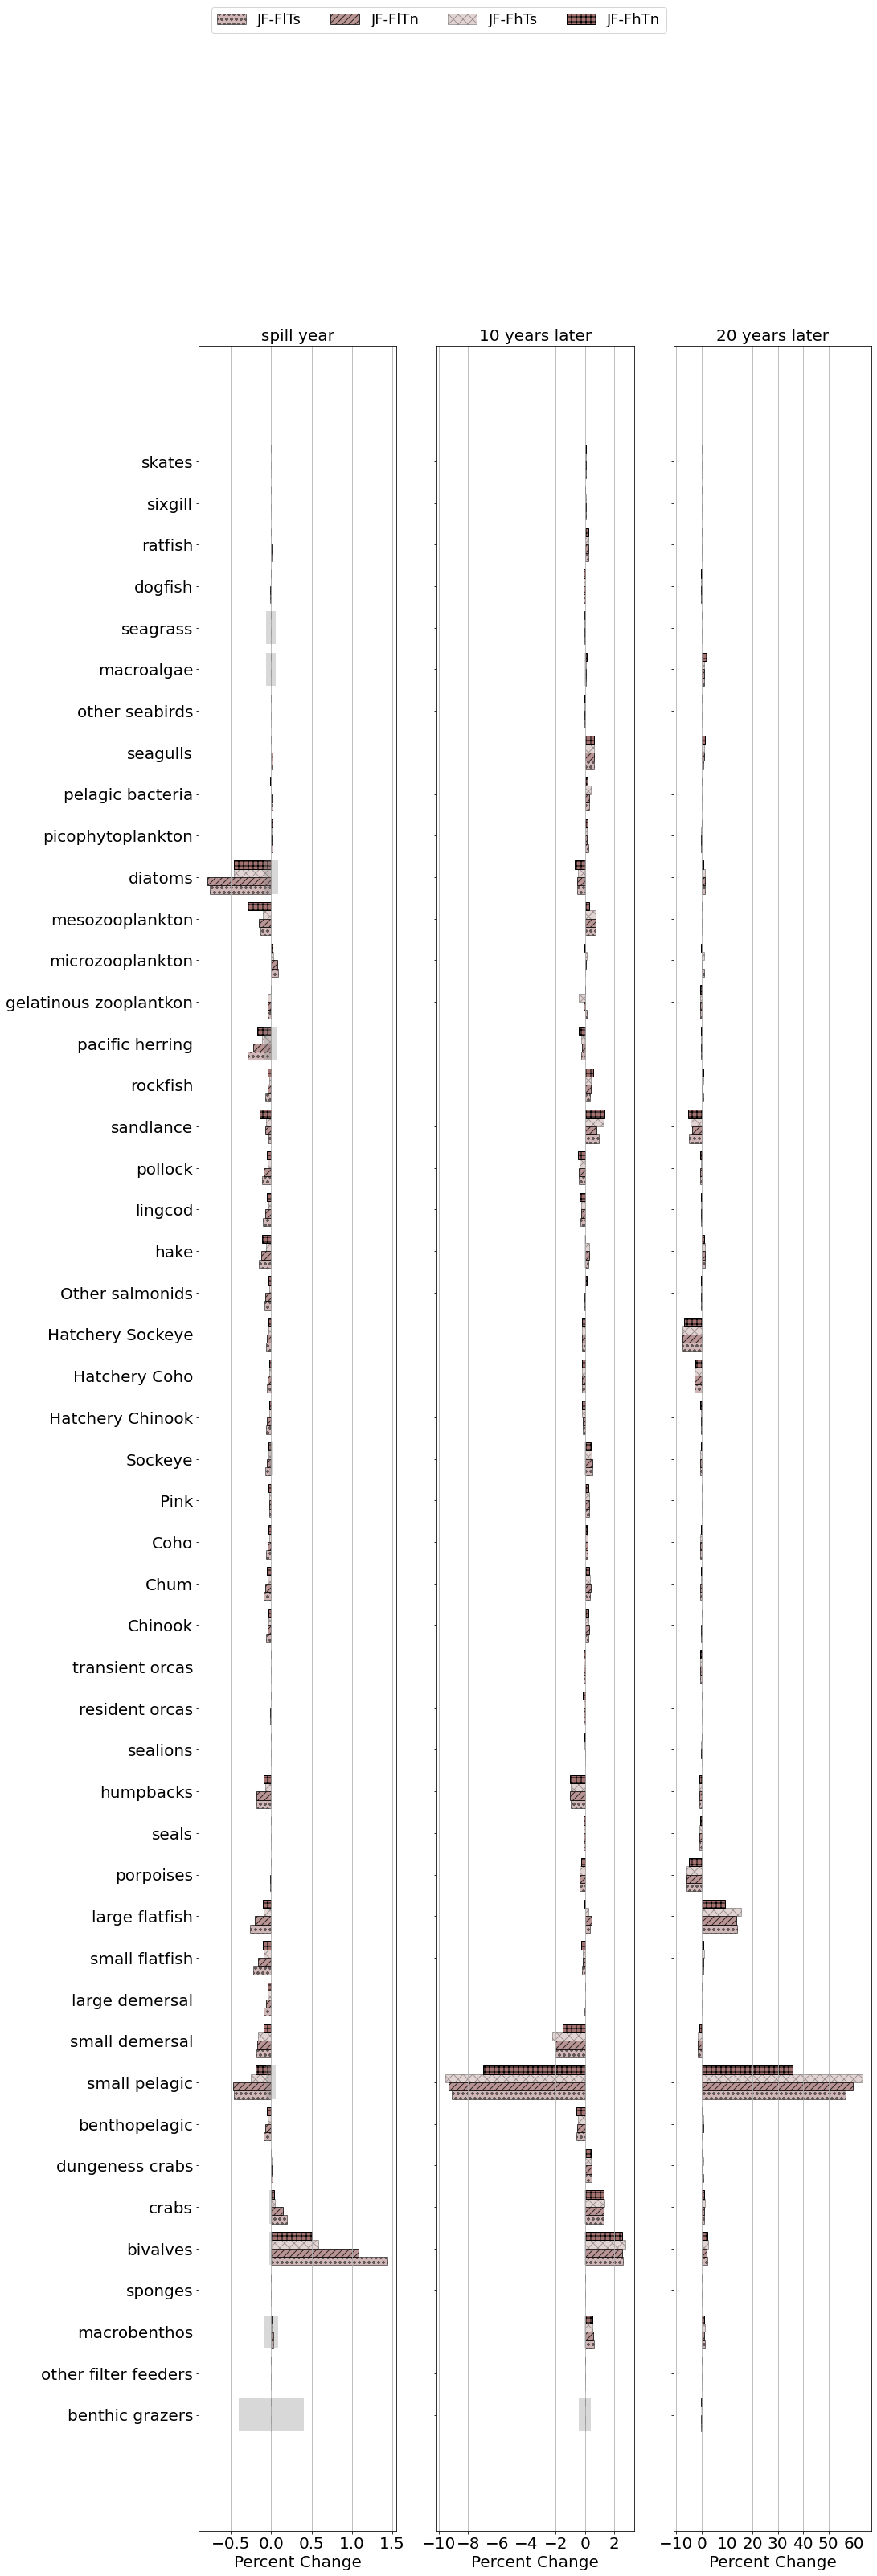

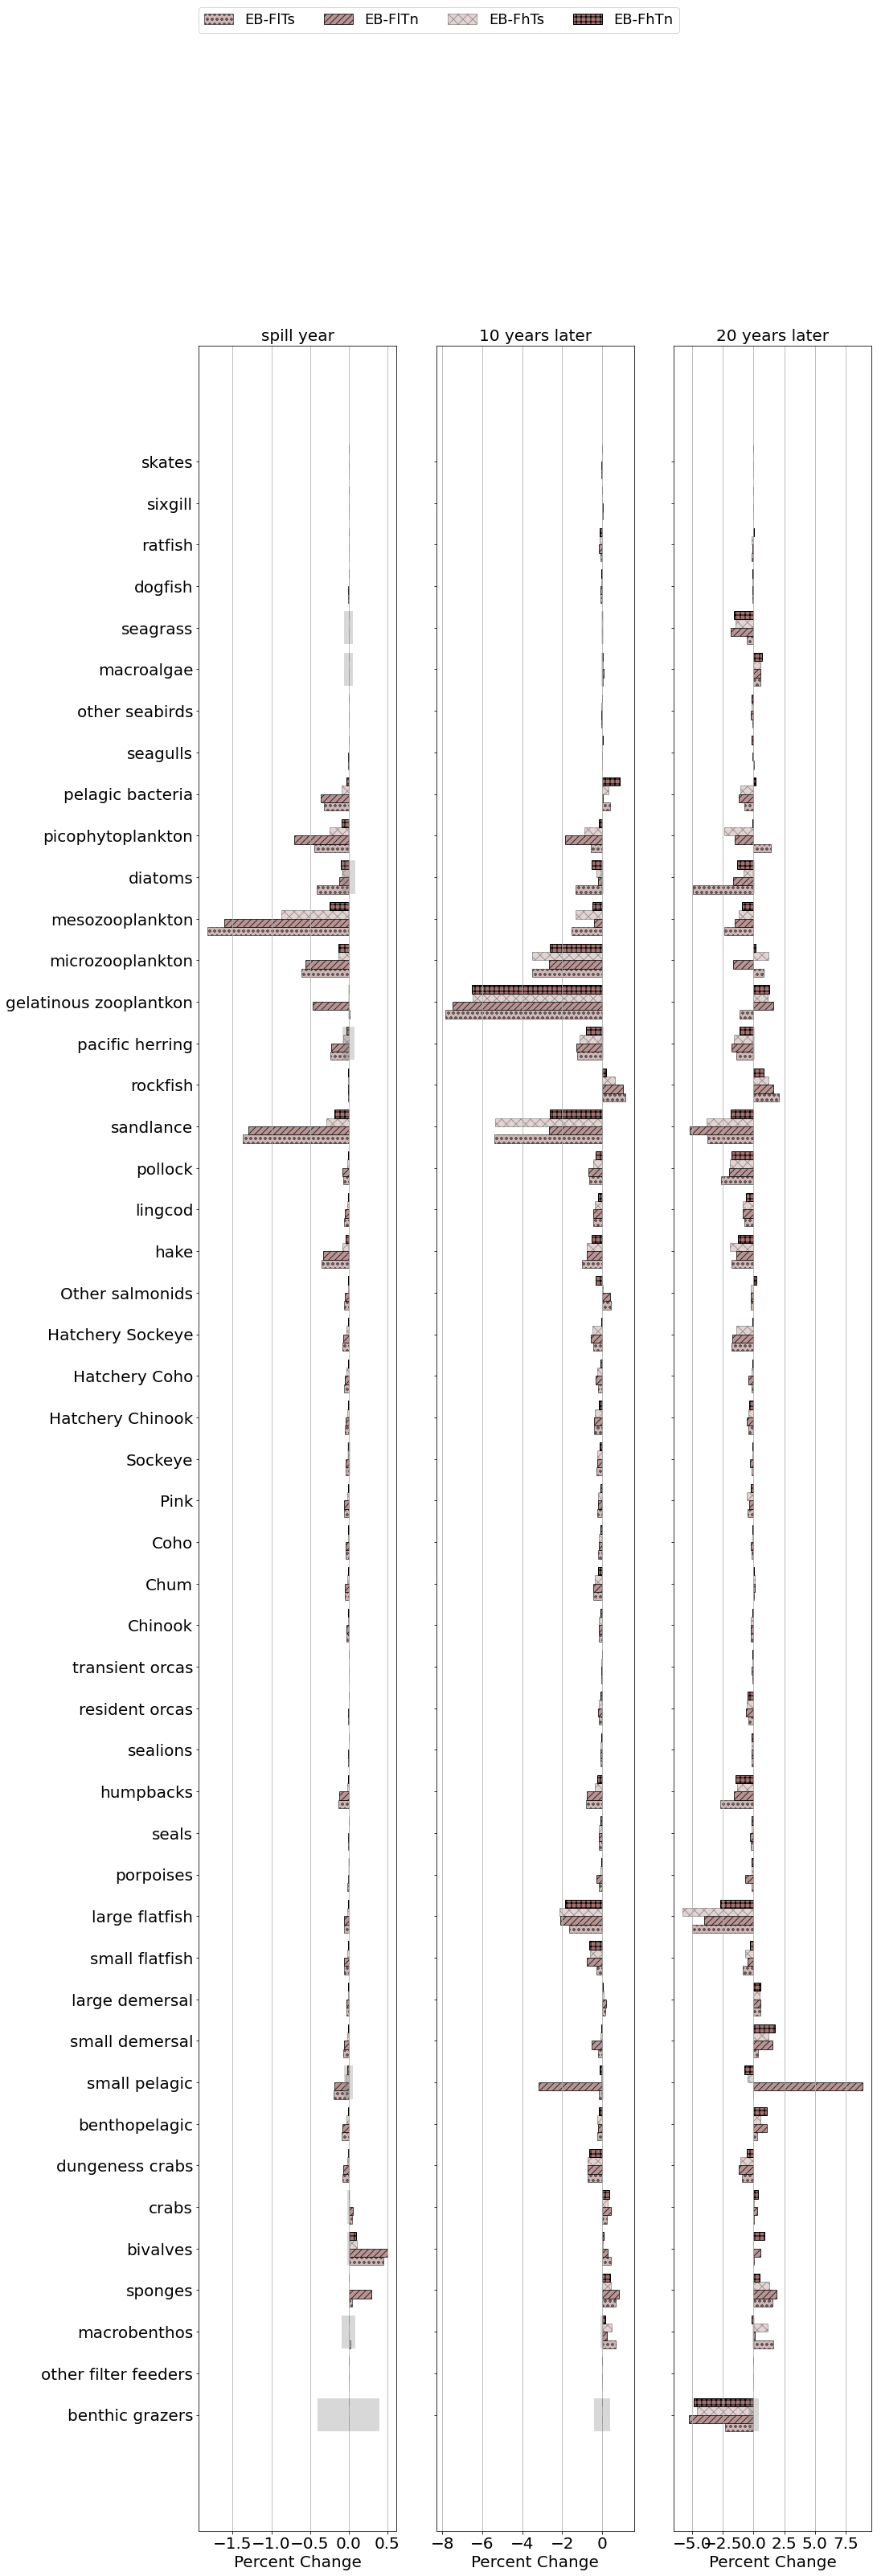

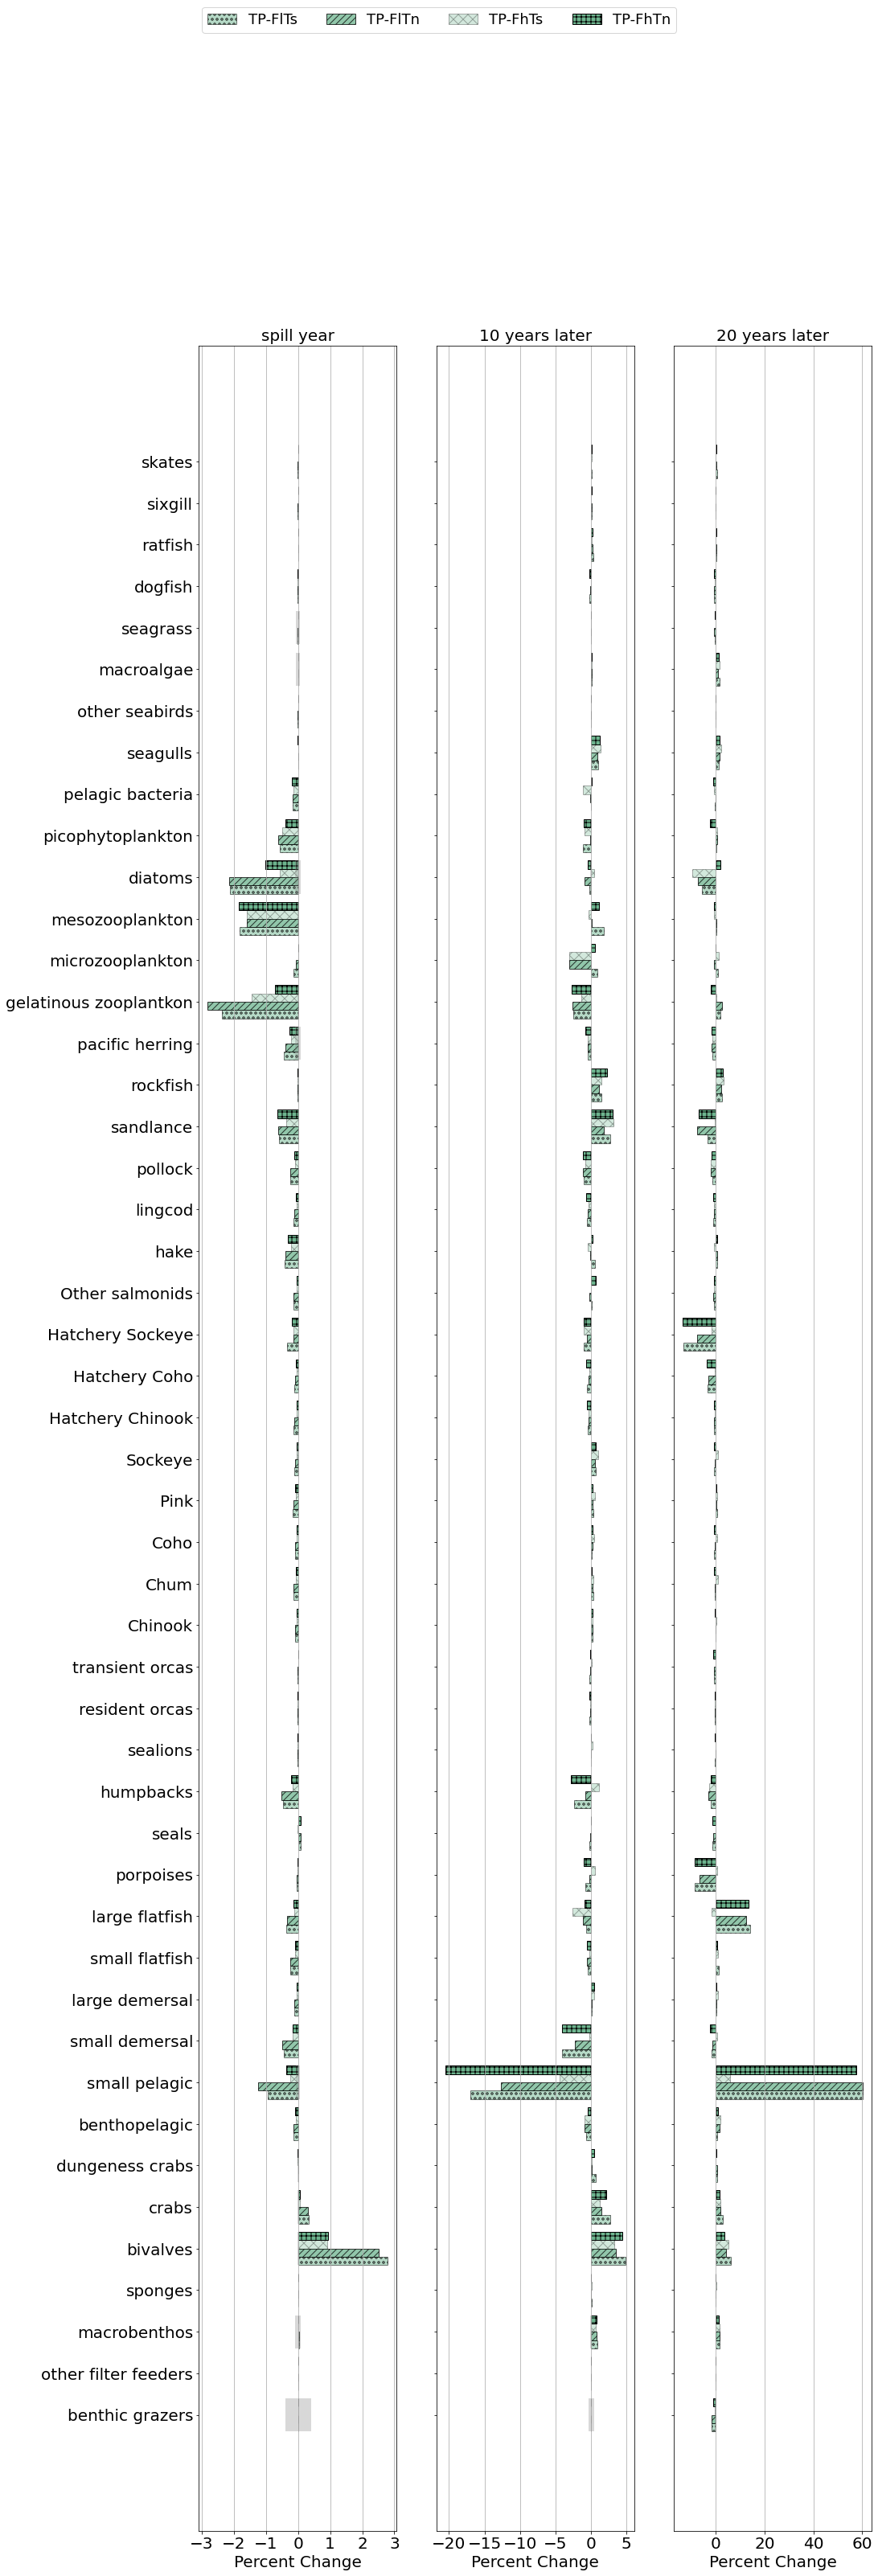

In [27]:
x_lim = None
for code_name in code_names:
    df_plot = []
    if code_name == 'AP':
        hex_colour = '#863092'
        #bio_groups = ['porpoises','seals','sealions','seagulls','other seabirds']
        #x_lim = [-10, 2]
    elif code_name == 'TP':
        hex_colour = '#6DB48E'
        #bio_groups = ['resident orcas','Other salmonids','Hatchery Chinook','Hatchery Coho','Hatchery Sockeye','Chinook','Chum','Coho','Pink','Sockeye',]
        #x_lim = [-14, 2]
    elif code_name == 'EB':
        hex_colour = '#A27170' #2F61A4'
        #bio_groups = ['porpoises','seals','sealions','seagulls','other seabirds','benthic grazers', 'sponges','bivalves','crabs','dungeness crabs','benthopelagic','large demersal','small demersal','large flatfish', 'small flatfish',]
        #x_lim = None
    elif code_name == 'JF':
        hex_colour = '#A27170'
        #bio_groups = ['humpbacks','resident orcas','transient orcas','Chinook','Chum','Coho','Pink','Sockeye',]
        #x_lim = [-1.5, 1.5]
    
    n_rows = len(bio_groups)
    if n_rows < 7:
        n_rows = 7 #elif n_rows >9:    n_rows = 10
    else:
        n_rows = n_rows
    n_cols = len(time_labels)
    
    fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, n_rows+2), sharey=True)

    if n_cols == 1:
        axes = [axes]  

    
    these_scenarios = [code_name+'-'+conditions_with_letters['1'],code_name+'-'+conditions_with_letters['2'],
                        code_name+'-'+conditions_with_letters['3'],code_name+'-'+conditions_with_letters['4']]

    bar_width = 0.8 / len(these_scenarios)  
    y_pos = np.arange(len(bio_groups))

    for i, time in enumerate(time_labels):
        ax = axes[i]
        for j, scenario in enumerate(these_scenarios):
            df_plot = df[(df['time_label'] == time) & (df['scenario'] == scenario)]
            df_plot = df_plot.set_index('bio_group').reindex(bio_groups)  
            offset = (j - len(these_scenarios)/2) * bar_width + bar_width/2

            ax.barh(y_pos + offset, df_plot['percent_change'], height=bar_width, label=scenario, facecolor=hex_colour, alpha=alphas[j], edgecolor='black', hatch=hatches[j])
        ax.barh(bio_groups, df_plot['sensitivity'], label=scenario, color='grey', alpha=0.3)
        ax.barh(bio_groups, df_plot['sensitivity_negative'], label=scenario, color='grey', alpha=0.3)
        ax.xaxis.grid(True)
        xlabels = ax.get_xticklabels()
        plt.setp(xlabels, fontsize=20)
    
        ax.set_title(time, fontsize=20)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(bio_groups, fontsize=20) 
        ax.set_xlim(x_lim)
        ax.set_xlabel("Percent Change", fontsize=20)

    fig.legend(these_scenarios, loc='upper center', ncol=len(these_scenarios), fontsize=18) 
    fig.savefig("Figures/"+code_name+"-results.png", dpi=300, bbox_inches='tight')  
    plt.show()

In [ ]:
stop = stop

Plots of affected groups

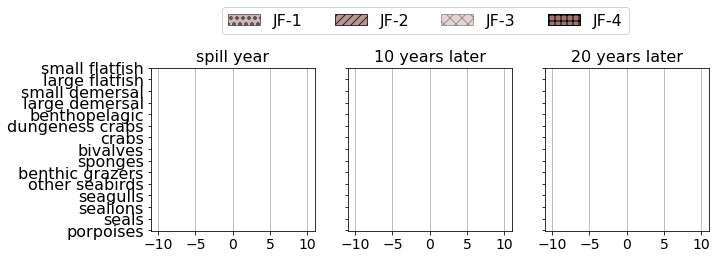

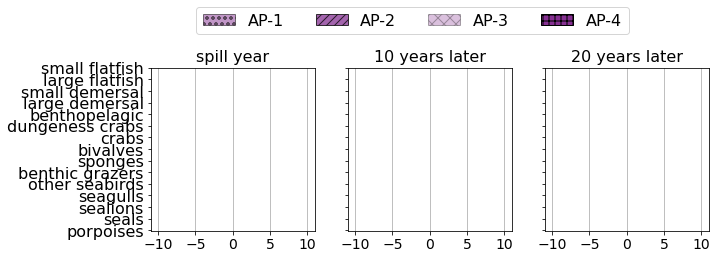

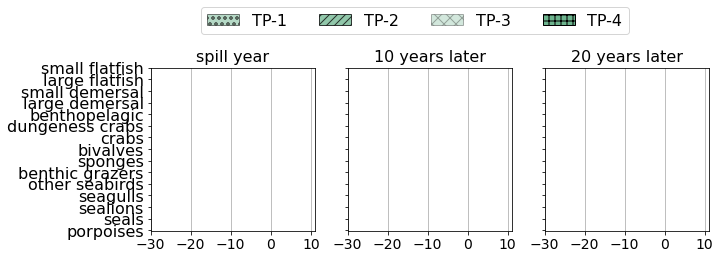

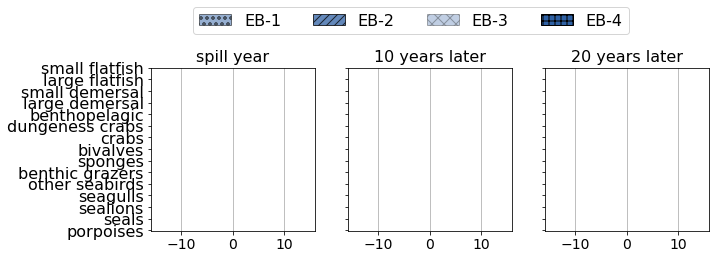

In [ ]:
for code_name in code_names:
    n_rows = len(bio_groups)
    if n_rows < 7:
        n_rows = 7
    elif n_rows >10:
        n_rows = 15
    else:
            n_rows = n_rows
    n_cols = len(time_labels)
    fig, axes = plt.subplots(1, n_cols, figsize=(10, 3), sharey=True)

    if n_cols == 1:
        axes = [axes]  

    if code_name == 'AP':
        hex_colour = '#863092'
        x_lim = [-11, 11]
    elif code_name == 'TP':
        hex_colour = '#6DB48E'
        x_lim = [-30, 11]
    elif code_name == 'EB':
        hex_colour = '#2F61A4'
        x_lim = [-16, 16]
    elif code_name == 'JF':
        hex_colour = '#A27170'
        x_lim = [-11, 11]
    
    these_scenarios = [code_name+'-1',code_name+'-2',code_name+'-3',code_name+'-4']

    bar_width = 0.9 / len(these_scenarios)  
    y_pos = np.arange(len(bio_groups))

    for i, time in enumerate(time_labels):
        ax = axes[i]
        for j, scenario in enumerate(these_scenarios):
            df_plot = df[(df['time_label'] == time) & (df['scenario'] == scenario)]
            df_plot = df_plot.set_index('bio_group').reindex(bio_groups)  
            offset = (j - len(these_scenarios)/2) * bar_width + bar_width/2

            ax.barh(y_pos + offset, df_plot['percent_change'], height=bar_width, label=scenario, facecolor=hex_colour, alpha=alphas[j], edgecolor='black', hatch=hatches[j])
        ax.barh(bio_groups, df_plot['sensitivity'], label=scenario, color='grey', alpha=0.3)
        ax.barh(bio_groups, df_plot['sensitivity_negative'], label=scenario, color='grey', alpha=0.3)
        ax.xaxis.grid(True)
        xlabels = ax.get_xticklabels()
        plt.setp(xlabels, fontsize=14)
    
        ax.set_title(time, fontsize=16)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(bio_groups, fontsize=16) 
        ax.set_xlim(x_lim)
        #ax.set_xlabel("Percent Change", fontsize=16)

    fig.legend(these_scenarios, ncol=len(these_scenarios), bbox_to_anchor=(0.8, 1.2), fontsize=16) 
    plt.show()